In [3]:
from utils import *
from genData import *
from model.unet_leaky_norm_tanho import UNet
import time 
np.random.seed(111)
torch.manual_seed(111)


In [ ]:
import numpy as np
import torch
from tqdm import tqdm

# Load the datasets
data_D120 = np.load('data_D120.npz', allow_pickle=True)
labels_D120 = data_D120['labels']
predictions_D120 = data_D120['predictions']

data_D35 = np.load('data_D35.npz', allow_pickle=True)
labels_D35 = data_D35['labels']
predictions_D35 = data_D35['predictions']

# Find unique labels and common labels
unique_labels_D120 = np.unique(labels_D120)
unique_labels_D35 = np.unique(labels_D35)
common_labels = np.intersect1d(unique_labels_D120, unique_labels_D35)

# Initialize results dictionaries for both datasets
results_dict_D120 = {}
results_dict_D35 = {}

# Define the detection statistic function
def compute_detection_statistic(images, ref_distribution=None):
    """
    Compute the KL divergence detection statistic for each image.

    Parameters:
        images (torch.Tensor): Input images, shape (batch_size, C, H, W).
        ref_distribution (np.ndarray): Reference distribution Q for KL divergence, 
                                      shape (H, W).

    Returns:
        np.ndarray: KL divergence statistics for each image.
    """
    detection_stats = np.mean(np.abs(images.transpose(0, 2, 3, 1)), axis=(1, 2, 3))
    return detection_stats

# Reference distribution (optional, not used in the function but included as per your code)
ref_one = np.ones_like(predictions_D120[0][0, :, :])  # Shape (H, W), e.g., (256, 128)

# Process dataset D120
print("Processing data_D120...")
for label in tqdm(common_labels):
    # Find indices where labels match the current common label
    indices = np.where(labels_D120 == label)[0]
    if len(indices) > 0:  # Only process if there are matching samples
        # Extract predictions for the common label
        pred_subset = predictions_D120[indices]
        # Compute detection statistic
        results_dict_D120[label] = compute_detection_statistic(pred_subset)

# Process dataset D35
print("Processing data_D35...")
for label in tqdm(common_labels):
    # Find indices where labels match the current common label
    indices = np.where(labels_D35 == label)[0]
    if len(indices) > 0:  # Only process if there are matching samples
        # Extract predictions for the common label
        pred_subset = predictions_D35[indices]
        # Compute detection statistic
        results_dict_D35[label] = compute_detection_statistic(pred_subset)

# Print results
print("\nDetection statistics for data_D120:")
for label, stat in results_dict_D120.items():
    print(f"Label {label}: {stat}")

print("\nDetection statistics for data_D35:")
for label, stat in results_dict_D35.items():
    print(f"Label {label}: {stat}")

In [12]:
common_labels

array([ 9., 12., 15., 18., 20., 22., inf])

(array([37.,  5., 61., 59., 52., 60., 54., 41., 22.,  9.]),
 array([0.00033993, 0.00096362, 0.00158732, 0.00221102, 0.00283472,
        0.00345841, 0.00408211, 0.00470581, 0.00532951, 0.0059532 ,
        0.0065769 ]),
 [<matplotlib.patches.Polygon at 0x14eecffdda30>])

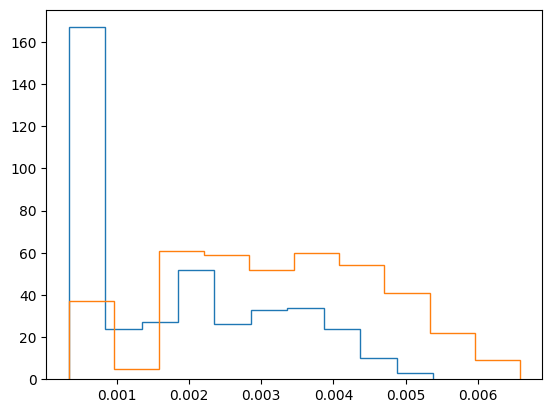

In [20]:
import matplotlib.pyplot as plt
plt.hist(results_dict_D120[np.float(20)], histtype='step')
plt.hist(results_dict_D35[np.float(20)], histtype='step')

In [8]:
ref_one = np.ones_like(predictions[0][0,:,:]) 
#ref_one = np.random.rand(256,128)

results_dict = {}

def compute_detection_statistic(images, ref_distribution=None):
    """
    Compute the KL divergence detection statistic for each image.

    Parameters:
        images (torch.Tensor): Input images, shape (batch_size, C, H, W).
        ref_distribution (np.ndarray): Reference distribution Q for KL divergence, 
                                        shape (H, W).

    Returns:
        np.ndarray: KL divergence statistics for each image.
    """
    detection_stats = np.mean(np.abs(images.transpose(0, 2, 3, 1)), axis=(1, 2, 3))
    #detection_stats = np.mean(np.abs(images.transpose(0, 2, 3, 1)), axis=(1, 2))
    return detection_stats

unique_labels = np.unique(labels)  # Find unique labels in the dataset
for label in tqdm(unique_labels):
    indices = np.where(labels == label)[0]
    
    results_dict[label] = compute_detection_statistic(predictions[indices])


100%|██████████| 7/7 [00:00<00:00,  8.28it/s]


In [11]:
from plot import *

In [27]:

depth = []
pdet = []
plt.figure(figsize=(8, 6))
mask_dict = {}
for key in results_dict.keys():
    #if key != np.inf:
    mask = np.zeros(results_dict[key].size, dtype=bool)
    data = results_dict[key]
        #print((data>x_pfa[j]).shape)
    mask = (data>x_pfa)
    mask_dict[key] = mask
    if key != np.inf:
        depth.append( int(key))
        pdet.append( mask.sum()/data.size )


depth = np.array(depth)
pdet = np.array(pdet)


<Figure size 800x600 with 0 Axes>

In [30]:
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy import stats
from PIL import Image
# Matplotlib configuration for consistent, readable plots
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 20
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import warnings

class fitSigmoid:    
    def __init__(self, nInj=100):
        self.nInj = nInj         # number of injections per point

    def sigmoid(self, x, k, x0):
        return 1./(1.+np.exp(-k*(x-x0))) 

    def inv_sigmoid(self, y, k, x0):
        return -np.log(1./y-1.) /k +x0        

    def transfromX(self, d):
        return d/self.dmax *2 - 1 
    
    def transfromD(self, x):
        return (x+1)/2*self.dmax 
    
    def binomialError(self, y, n):
        err =  np.sqrt(y*(1.-y)/n)
        err[err==0] = 1./n
        return err

    def d_fromPercentile(self, per=0.9):    
        x = self.inv_sigmoid(per, *self.popt)
        d = self.transfromD(x)
        a, b = self.popt.T
        dxda =  -1.0/a**2 * np.log(per/(1-per))
        dxdb = 1.0
        dx = np.sqrt(self.pcov[0,0]*dxda**2 + self.pcov[1,1]*dxdb**2 + 2*self.pcov[0,1]*dxda*dxdb)

        return d, dx

    def fit(self, d, p):        
        self.dmax = np.max(d)
        err = self.binomialError(p, self.nInj)
        x = self.transfromX(d)
        self.popt, self.pcov = curve_fit(self.sigmoid, x, p, p0=[0,100], sigma=err) 
        return 0
    
    def plot(self, cosi, d_list, p, savePath='./sigmoid.pdf'):
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 
        
        
        d_low, _ = self.d_fromPercentile(per=0.001)
        d_high, _ = self.d_fromPercentile(per=0.999)
        d_low, d_high = min(d_list[0], d_low), max(d_list[-1],d_high)
        d_arr = np.linspace(d_low, d_high, 100)
        x_arr = self.transfromX(d_arr)
        
        p_inter = self.sigmoid(x_arr, *self.popt)
        ax.plot(d_arr, p_inter, color=colors[0], label='fit')
                 
        ax.scatter(d_list, p, color='black')
        err = self.binomialError(p, self.nInj)
        ax.errorbar(d_list, p, yerr=err, fmt='', color='k', ls='none')
               
        d90, dx = self.d_fromPercentile(per=0.9)
        dx = dx /2 * self.dmax
        p90 = 0.9
        x_highlighting = [0, d90, d90]
        y_highlighting = [p90, p90, -1]

        if cosi is None:
            plt.plot(x_highlighting, y_highlighting, color='r', label=r'$\mathcal{D}^{90\%}=$'+'{:.1f}'.format(d90)+r'$\pm$'+'{:.1f}'.format(np.abs(dx)))
        else:
            plt.plot(x_highlighting, y_highlighting, color='r', label=r'$\mathcal{D}^{90\%}=$'+'{:.1f}'.format(d90)+r'$\pm$'+'{:.1f}'.format(np.abs(dx))+r'$\; (\cos \iota =$'+str(cosi)+')')

        ax.legend()
        ax.set_ylim(-0.05, 1.05)
        #ax.set_xlim(0.9*min(min(d_list), d_arr[0]), 1.05*min(max(d_list), max(d_arr)))       
        plt.xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$')
        ax.set_ylabel(r'$p_{\mathrm{det}}$')
        #plt.legend(loc=3)
        ax.set_xlim(0.9*min(min(d_list), d_arr[0]), 1.0*50)       
        plt.grid(alpha=1, which='major')
        plt.grid(alpha=0.3, which='minor')
        plt.minorticks_on() 
        #fig.savefig(savePath)
        return fig
    

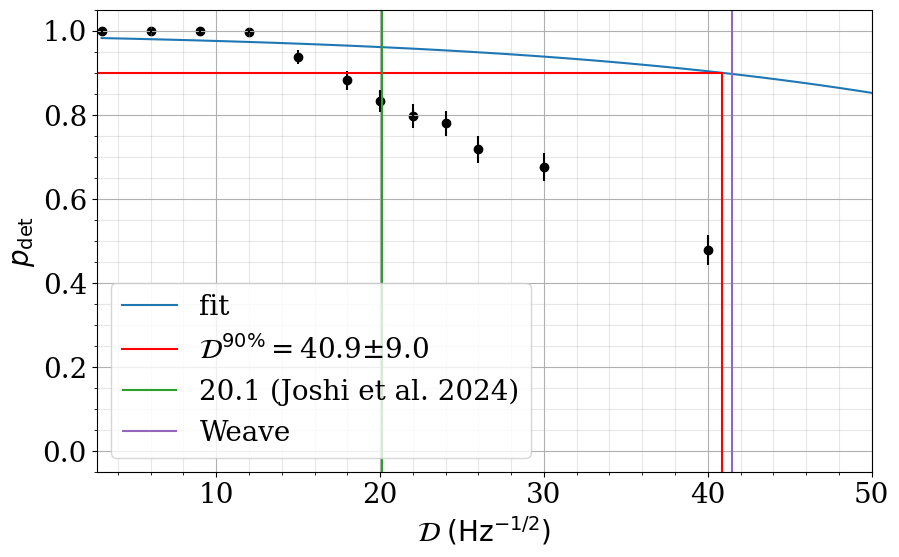

In [31]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 
fit = fitSigmoid(200)
fit.fit(depth, pdet)
fig = fit.plot(None, depth, pdet)
depth_joshi = 20.1
plt.vlines(x=depth_joshi, ymin=-1,ymax=2, color=colors[2], label='{} (Joshi et al. 2024)'.format(depth_joshi))
depth_weave = 41.5
plt.vlines(x=depth_weave, ymin=-1,ymax=2, color=colors[4], label='Weave')

plt.legend()
#plt.savefig('./plots/pdet_{}_3+1day_gaps.pdf'.format(version))
#plt.savefig('./plots/pdet_{}.pdf'.format(version))
#plt.savefig('./plots/pdet_{}.png'.format(version))
plt.show()

In [22]:
max_train_levels = [0, 3, 6, 9, 12,
             15, 18, 20, 22, 
             24, 26, 30, 40, 
             60, 80, 100, 120]
filename = '/scratch/kriles_root/kriles0/damoncht/unet_dyn_fastnoise/data/validation/200Hz_H1L1_D0-35_256x128_7200s_4c_traindata_n200_norm.npz'
filename = '/scratch/kriles_root/kriles0/damoncht/unet_dyn_fastnoise/data/validation/200Hz_H1L1_D0-120_256x128_7200s_4c_traindata_n100_norm.npz'

print("Using {}".format(filename))
data = np.load(filename, allow_pickle=True)


Using /scratch/kriles_root/kriles0/damoncht/unet_dyn_fastnoise/data/validation/200Hz_H1L1_D0-120_256x128_7200s_4c_traindata_n100_norm.npz


In [40]:

depth = []
pdet = []
plt.figure(figsize=(8, 6))
mask_dict = {}
for key in results_dict.keys():
    #if key != np.inf:
    mask = np.zeros(results_dict[key].size, dtype=bool)
    data = results_dict[key]
    mask = (data>x_pfa)
    mask_dict[key] = mask
    if key != np.inf:
        depth.append( int(key))
        pdet.append( mask.sum()/data.size )

depth = np.array(depth)
pdet = np.array(pdet)


400
400
400
400
400
400
400
400
400
400
400
400
400
400
400
400


<Figure size 800x600 with 0 Axes>

In [19]:
x_pfa

0.00043354555818950755

In [18]:
params = data['params'][:, :-1]  # All parameters except the last one
param_names = ['f1', 'cosi', 'phi', 'psi', 'alpha', 'delta']
# Identify indices for level=30 and missed signals
level_30_indices = np.where(labels == 22)[0]  # Indices where label is 30
missed_indices = level_30_indices[~mask_dict[np.float(22)]]  # Missed signals (mask_dict[30] == False)

# Parameters for all samples and missed signals
all_params = params  # Shape: (n_samples, n_params)
missed_params = params[missed_indices]  # Parameters of missed signals at level=30

# Create the corner plot
figure = corner(
    all_params,
    labels=param_names,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    color='blue',
    alpha=0.5,
    hist_kwargs={'density': True}
)

# Overlay missed signals at level=30
corner(
    missed_params,
    fig=figure,
    color='red',
    alpha=0.8,
    labels=param_names,
    hist_kwargs={'density': True, 'label': 'Missed (level=30)'}
)

# Add legend to distinguish missed signals
plt.legend(handles=[
    plt.Line2D([0], [0], color='blue', label='All Samples'),
    plt.Line2D([0], [0], color='red', label='Missed (level=30)')
], fontsize=12, loc='upper right')

plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

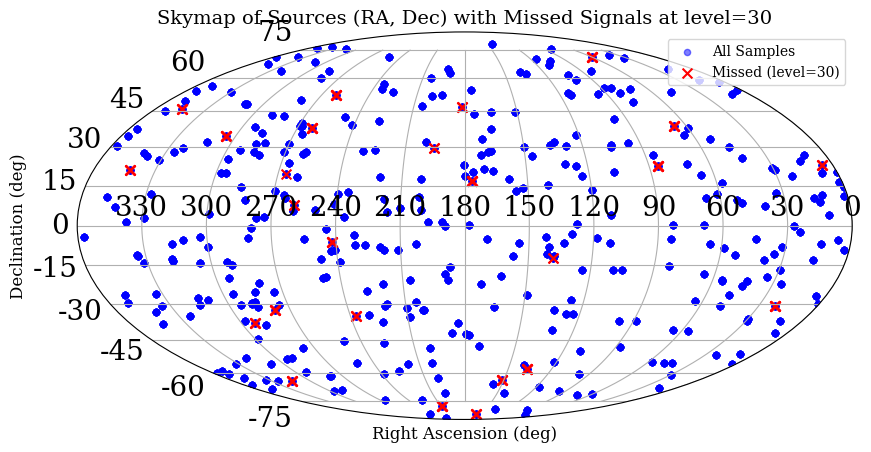

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

# Extract RA (alpha) and Dec (delta) from data['params'][:, :-1]
# Assuming alpha is column 0 (in radians) and delta is column 1 (in degrees)
alpha_rad = data['params'][:, -3]  # RA in radians (0 to 2π)
delta = data['params'][:, -2]  # Dec in degrees (-90 to 90)

# Convert alpha from radians to degrees (0 to 360)
alpha_deg = np.degrees(alpha_rad)

# Identify indices for level=30 and missed signals
level_30_indices = np.where(labels == 22)[0]  # Indices where label is 30
missed_indices = level_30_indices[~mask_dict[22]]  # Missed signals (mask_dict[30] == False)

# Convert RA to radians for Mollweide projection (and reverse for astronomical convention)
ra_plot_rad = np.radians(180 - alpha_deg)  # RA in degrees (0 to 360) -> radians, mirrored
dec_plot_rad = delta  # Dec in degrees -> radians

# RA and Dec for missed signals
ra_missed = ra_plot_rad[missed_indices]
dec_missed = dec_plot_rad[missed_indices]

# Create the skymap
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='mollweide')

# Plot all samples
ax.scatter(ra_plot_rad, dec_plot_rad, c='blue', s=20, alpha=0.5, label='All Samples')

# Plot missed signals at level=30
ax.scatter(ra_missed, dec_missed, c='red', s=50, marker='x', label='Missed (level=30)')

# Customize the plot
ax.set_xlabel('Right Ascension (deg)', fontsize=12)
ax.set_ylabel('Declination (deg)', fontsize=12)
ax.grid(True)

# Set RA ticks (in degrees, reversed for astronomical convention)
ra_ticks_deg = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210, 180])
ra_ticks_rad = np.radians(180 - ra_ticks_deg)
ax.set_xticks(ra_ticks_rad)
ax.set_xticklabels([f'{t:.0f}' for t in ra_ticks_deg])

# Set Dec ticks
dec_ticks_deg = np.array([-75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75])
dec_ticks_rad = np.radians(dec_ticks_deg)
ax.set_yticks(dec_ticks_rad)
ax.set_yticklabels([f'{t:.0f}' for t in dec_ticks_deg])

# Add legend
plt.legend(loc='upper right', fontsize=10)

# Title
plt.title('Skymap of Sources (RA, Dec) with Missed Signals at level=30', fontsize=14)

plt.show()